In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

import warnings
warnings.filterwarnings('ignore')

In [7]:
df=pd.read_csv("/kaggle/input/datasets/mithrareddymadapa/car-price/CarPrice_Assignment.csv")

**Data checks to perform**
1. check missing values
2. check duplicate values
3. check datatypes
4. check for unique values in the each column
6. check statistics of the dataset
7. check various categories present in different categorical columns 

In [8]:
#check missing values of entire dataset by showing
df.isnull()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
201,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
202,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
203,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
#check missing values in entire dataset 
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [10]:
#check duplicate values 
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
200    False
201    False
202    False
203    False
204    False
Length: 205, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
#check datatypes
df.dtypes

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

In [13]:
#check for no.of unique values
df.nunique()

car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
dtype: int64

In [14]:
#check statistics of data 
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [15]:
#check various categories present in categorical column 
categorical_columns=['fueltype','aspiration','doornumber','carbody','drivewheel','enginelocation','enginetype',
                'cylindernumber','fuelsystem']
for col in categorical_columns:
    print(f"category of {col} is : {df[col].unique()}")
print("--------------------------")
for col in categorical_columns:
    print(f"category of {col} is: {df[col].nunique()}")

category of fueltype is : ['gas' 'diesel']
category of aspiration is : ['std' 'turbo']
category of doornumber is : ['two' 'four']
category of carbody is : ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
category of drivewheel is : ['rwd' 'fwd' '4wd']
category of enginelocation is : ['front' 'rear']
category of enginetype is : ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']
category of cylindernumber is : ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
category of fuelsystem is : ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']
--------------------------
category of fueltype is: 2
category of aspiration is: 2
category of doornumber is: 2
category of carbody is: 5
category of drivewheel is: 3
category of enginelocation is: 2
category of enginetype is: 7
category of cylindernumber is: 7
category of fuelsystem is: 8


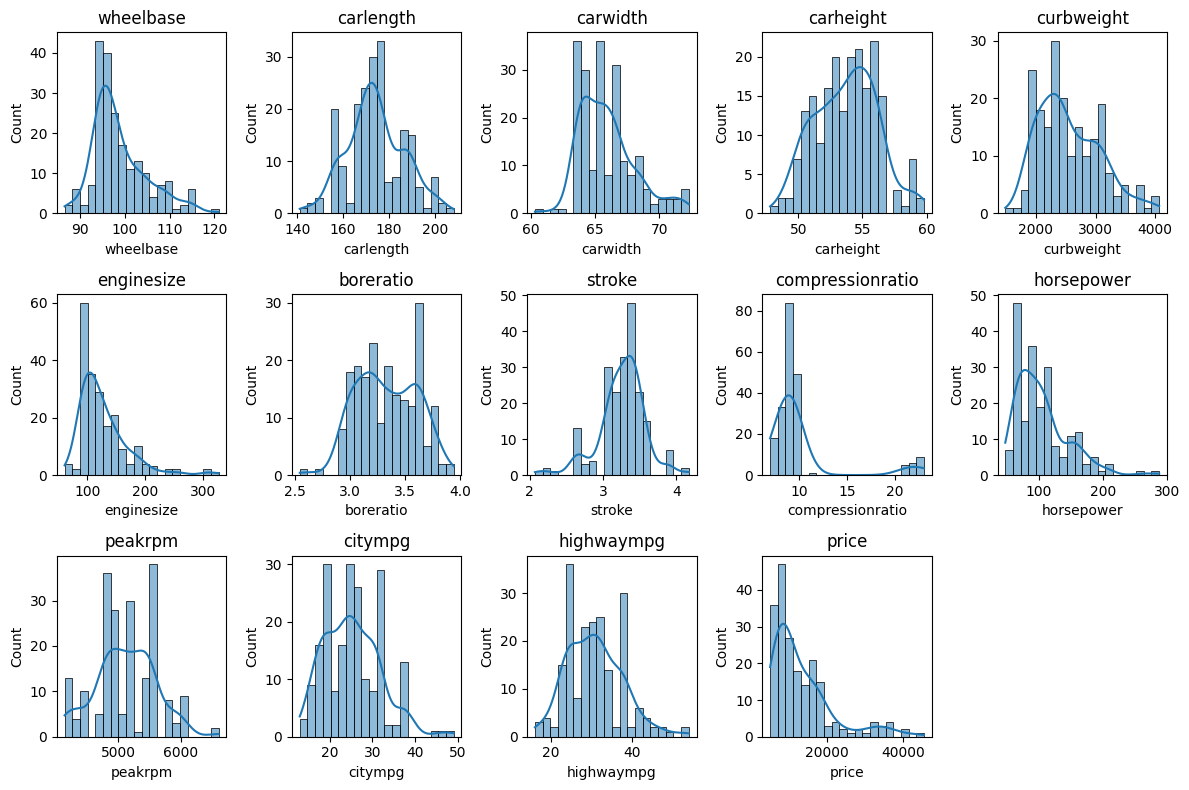

In [20]:
#exploratory data analysis 
numerical_features=['wheelbase','carlength','carwidth','carheight','curbweight','enginesize','boreratio','stroke','compressionratio','horsepower','peakrpm','citympg','highwaympg','price']
plt.figure(figsize=(12,8))
for feature in numerical_features:
    plt.subplot(3,5, numerical_features.index(feature)+1)
    sns.histplot(data=df[feature],bins=20, kde=True)
    plt.title(feature)
plt.tight_layout()
plt.show()


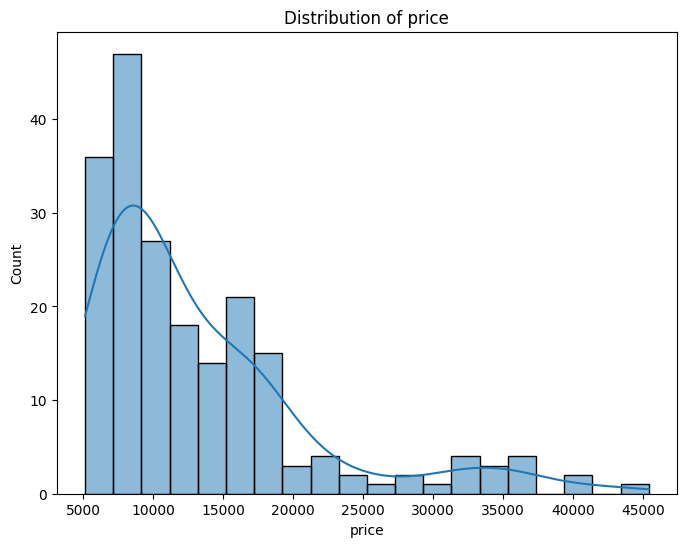

In [21]:
#price analysis 
plt.figure(figsize=(8,6))
sns.histplot(data=df['price'],bins=20,kde=True)
plt.title('Distribution of price')
plt.show()

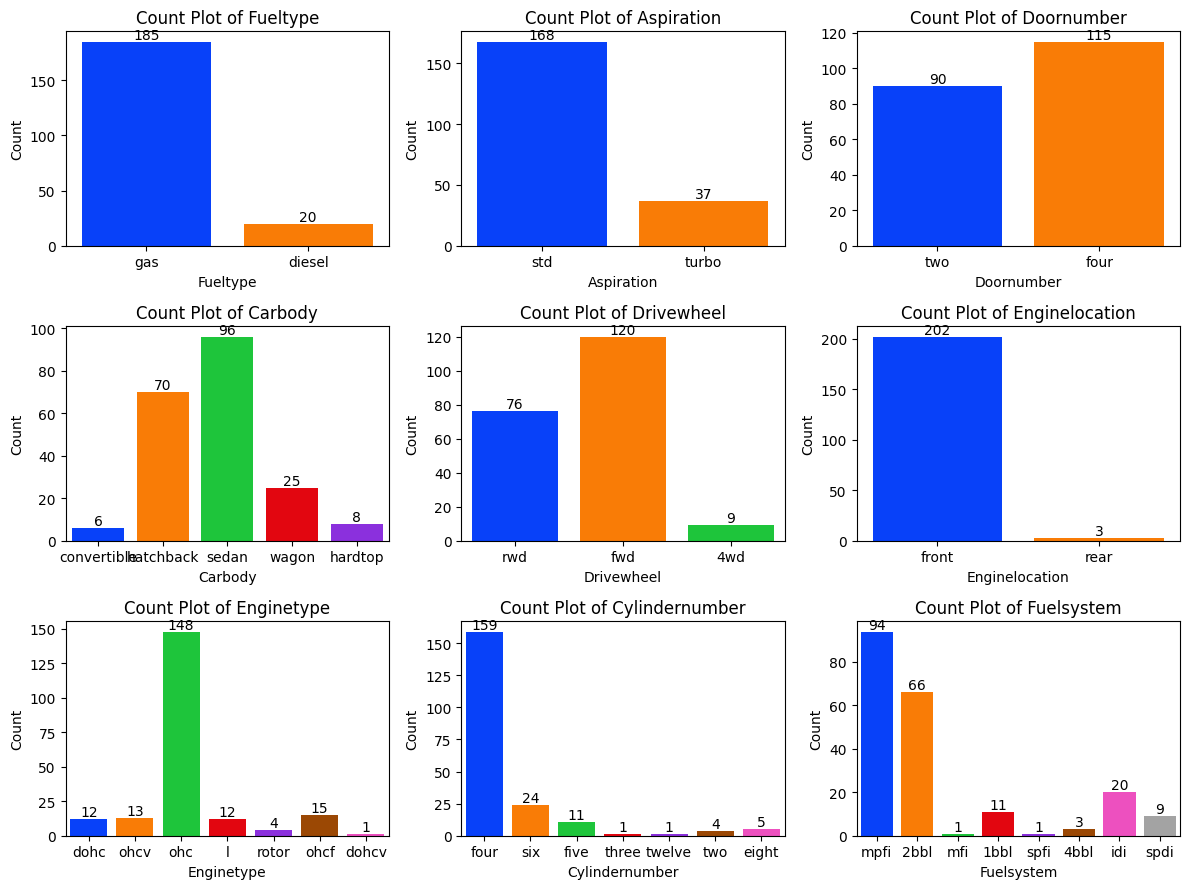

In [38]:
# Define the list of categorical columns to analyze
categorical_columns = ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
                       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 9))
axes = axes.ravel()  # Flatten the 2D array of axes

# Loop through each categorical column
for i, column in enumerate(categorical_columns):
    sns.countplot(x=df[column], data=df, palette='bright', ax=axes[i], saturation=0.95)
    for container in axes[i].containers:
        axes[i].bar_label(container, color='black', size=10)
    axes[i].set_title(f'Count Plot of {column.capitalize()}')
    axes[i].set_xlabel(column.capitalize())
    axes[i].set_ylabel('Count')

# Adjust layout and show plots
plt.tight_layout()
plt.show()

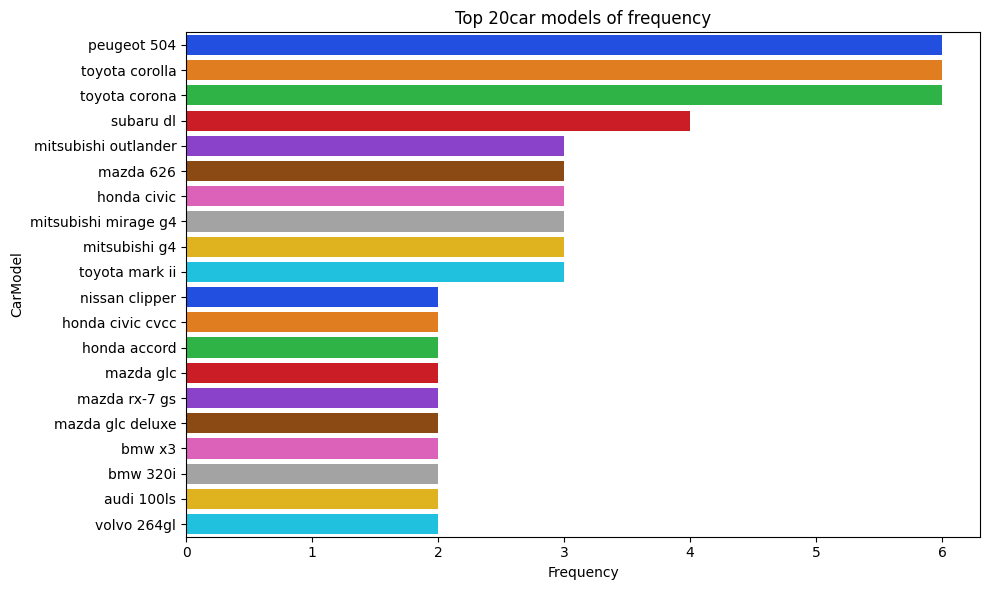

In [41]:
#no.of top car models to plot 
n=20
top_car_models=df['CarName'].value_counts().head(n)
plt.figure(figsize=(10,6))
sns.barplot(x=top_car_models.values, y=top_car_models.index, palette='bright', legend=False)
plt.title(f'Top {n}car models of frequency')
plt.xlabel('Frequency')
plt.ylabel('CarModel')
plt.tight_layout()
plt.show()

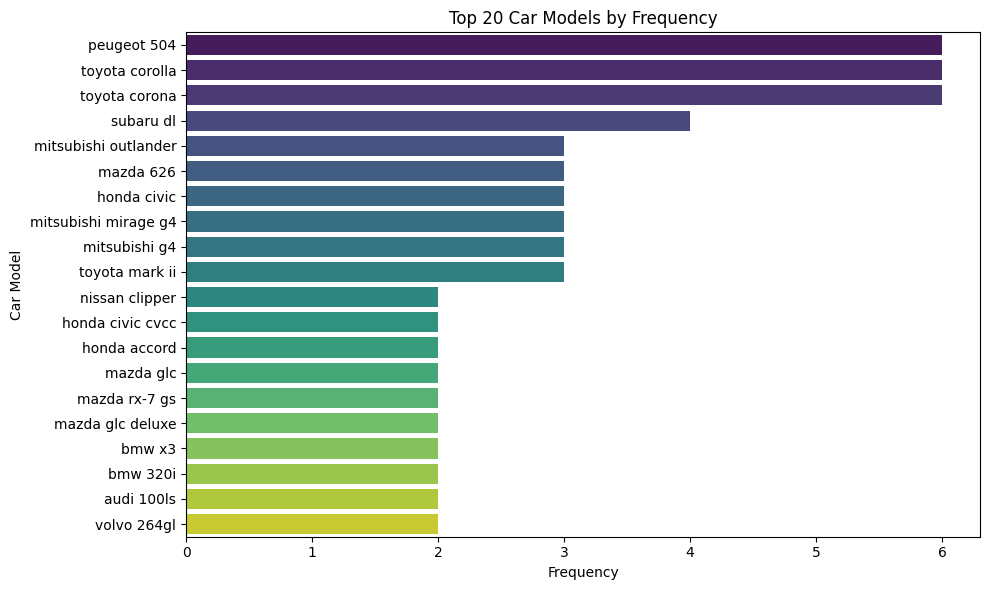

In [42]:
n = 20  # Number of top car models to plot
top_car_models = df['CarName'].value_counts().head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index, palette='viridis', legend=False)
plt.title(f'Top {n} Car Models by Frequency')
plt.xlabel('Frequency')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()

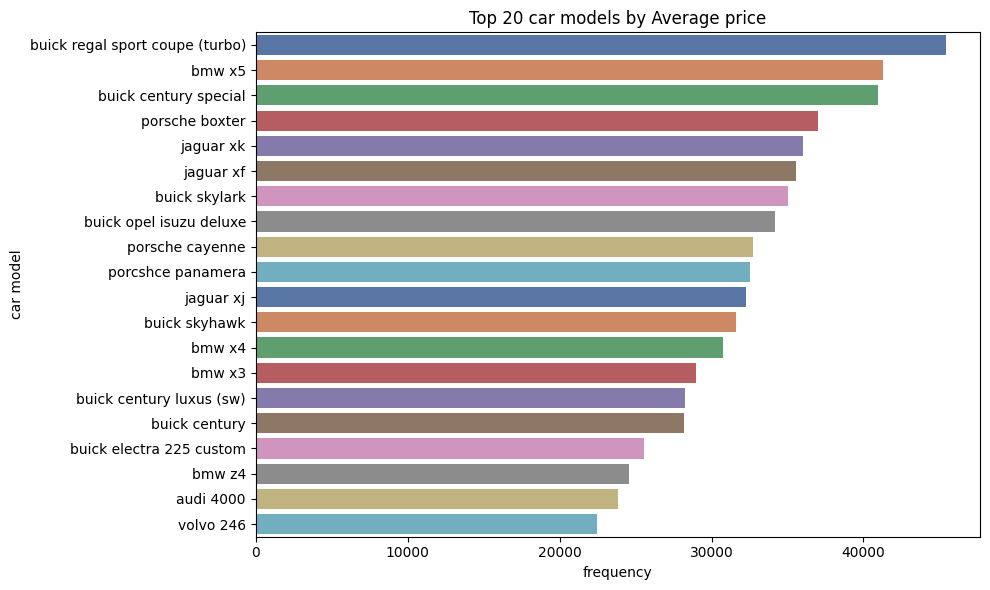

In [43]:
#calculate average price for each car model 
avg_price_by_car=df.groupby('CarName')['price'].mean().sort_values(ascending=False)
n=20
top_car_models=avg_price_by_car.head(n)
plt.figure(figsize=(10,6))
sns.barplot(x=top_car_models.values, y=top_car_models.index, palette='deep', legend=False)
plt.title(f'Top {n} car models by Average price')
plt.xlabel('frequency')
plt.ylabel('car model')
plt.tight_layout()
plt.show()

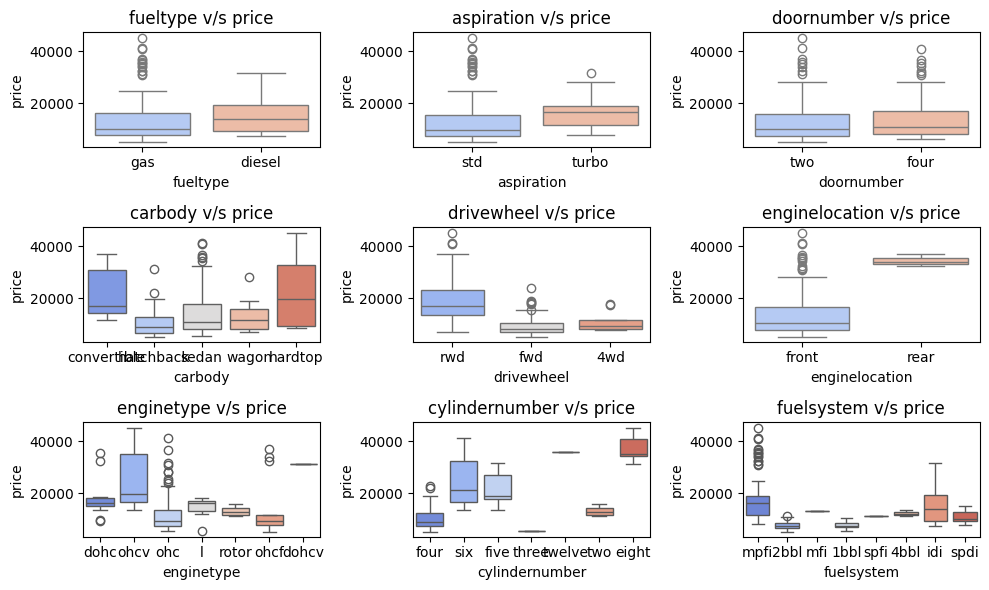

In [45]:
#categorical features v/s price 
plt.figure(figsize=(10,6))
for feature in categorical_columns:
    plt.subplot(3,3, categorical_columns.index(feature)+1)
    sns.boxplot(data=df, x=feature, y='price', palette='coolwarm',legend=False)
    plt.title(f'{feature} v/s price')
plt.tight_layout()
plt.show()

In [ ]:
#correlation analysis 
correlation_matrix=df[numerical_features].corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()